# Clustering Example
# K-Means, Agglomerative, and Gaussian Mixture Model

---

## Objective

This example applies three widely used clustering algorithms to the same real dataset, and visualize the resulting cluster assignments through three dimensionality reduction methods: PCA, t-SNE, and UMAP. 

| Algorithm | Core idea | Cluster assumption |
|:---|:---|:---|
| **K-Means** | Assigns each point to the nearest centroid; minimizes within-cluster variance | Spherical, equal-sized |
| **Agglomerative (Ward)** | Builds a hierarchy bottom-up by merging the pair of clusters that minimizes the increase in total within-cluster variance (Ward linkage)| Compact, hierarchically nested |
| **Gaussian Mixture Model (GMM)** | Models data as a mixture of Gaussians; assigns soft probabilistic membership to each component | Elliptical, can vary in shape and size |

The clustering algorithms are compared along two dimensions:

- Algorithmic assumptions — each method makes different assumptions about cluster geometry (spherical, hierarchically nested, or elliptical), which leads to different partitions of the same data.
- Evaluation — results are assessed both quantitatively (Adjusted Rand Index, Normalized Mutual Information, Silhouette score) and qualitatively through visualization.

The dimensionality reduction methods serve as complementary lenses for inspecting the cluster structure:

- **PCA** (Principal Component Analysis) provides a linear baseline projection that preserves global variance and yields interpretable axes.
- **t-SNE** (t-Distributed Stochastic Neighbor Embedding) reveals local neighborhood topology, often making cluster separation more visually apparent at the cost of distorting global distances.
- **UMAP** (Uniform Manifold Approximation and Projection) balances local and global structure, typically producing the clearest visual separation while remaining more faithful to the overall geometry of the data than t-SNE.

Together, the three projections illustrate how the choice of visualization method can substantially affect the apparent clarity of cluster boundaries — independently of which clustering algorithm produced the labels.

---

## UCI Wine Dataset 

Chemical analysis of **178 wines** from three cultivars grown in the same region of Italy. The 13 continuous features (alcohol content, flavanoids, colour intensity, etc.) are used as clustering input; the cultivar labels are held back and used only for evaluation.

- **Source:** Aeberhard & Forina (1991). *Wine* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5PC7J  
- **Available via:** `sklearn.datasets.load_wine()`

---

## Evaluation metrics

| Metric | What it measures | Notes |
|:---|:---|:---|
| **Adjusted Rand Index (ARI)** | Agreement between predicted clusters and true cultivar labels | 1 = perfect, 0 = random; requires ground truth |
| **Normalized Mutual Information (NMI)** | Shared information between predicted clusters and true labels, normalised to [0, 1] | 1 = perfect, 0 = no shared information; permutation-invariant |
| **Silhouette score** | How well each point fits its own cluster vs neighbors | –1 to 1; higher is better; no ground truth needed |

---
## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (adjusted_rand_score, silhouette_score,
                              normalized_mutual_info_score, confusion_matrix)
from scipy.cluster.hierarchy import dendrogram, linkage as sp_linkage

# Load data
wine = load_wine()
X_raw = wine.data
y_true = wine.target      # cultivar labels — held back from clustering

# Scale data - standardization
X = StandardScaler().fit_transform(X_raw)

# PCA for 2-D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Samples : {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Classes : {np.unique(y_true)}  ({np.bincount(y_true)} per cultivar)")
print(f"PCA variance explained by first two PCs: {pca.explained_variance_ratio_.sum():.1%}")

Samples : 178
Features: 13
Classes : [0 1 2]  ([59 71 48] per cultivar)
PCA variance explained by first two PCs: 55.4%


---
## 1. Fit the three clustering models

In [2]:
# K-Means clustering
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(X)

# Agglomerative clustering (Ward linkage) 
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg.fit(X)

# Gaussian Mixture Model
#   covariance_type='tied': all components share the same covariance matrix —
#   a middle ground between full flexibility and spherical (k-means) assumption.
gmm = GaussianMixture(n_components=3, covariance_type='tied', random_state=42)
gmm.fit(X)

labels = {
    'K-Means':              km.labels_,
    'Agglomerative (Ward)': agg.labels_,
    'GMM (tied cov.)':      gmm.predict(X),
}

print("Cluster sizes:")
for name, label in labels.items():
    print(f"  {name:<20}: {np.bincount(label)}")

Cluster sizes:
  K-Means             : [65 51 62]
  Agglomerative (Ward): [58 56 64]
  GMM (tied cov.)     : [66 50 62]


## 2. Evaluate and compare

In [3]:
rows = []
for name, label in labels.items():
    rows.append({
        'Method':      name,
        'ARI':         round(adjusted_rand_score(y_true, label), 4),
        'NMI':         round(normalized_mutual_info_score(y_true, label), 4),
        'Silhouette':  round(silhouette_score(X, label), 4),
        'Cluster sizes': str(np.bincount(label)),
    })

metrics_df = pd.DataFrame(rows).set_index('Method')
metrics_df

,ARI,NMI,Silhouette,Cluster sizes
Method,,,,
K-Means,0.8975,0.8759,0.2849,[65 51 62]
Agglomerative (Ward),0.7899,0.7865,0.2774,[58 56 64]
GMM (tied cov.),0.9134,0.8920,0.2843,[66 50 62]


## 3. Visualize cluster assignments (PCA projection)

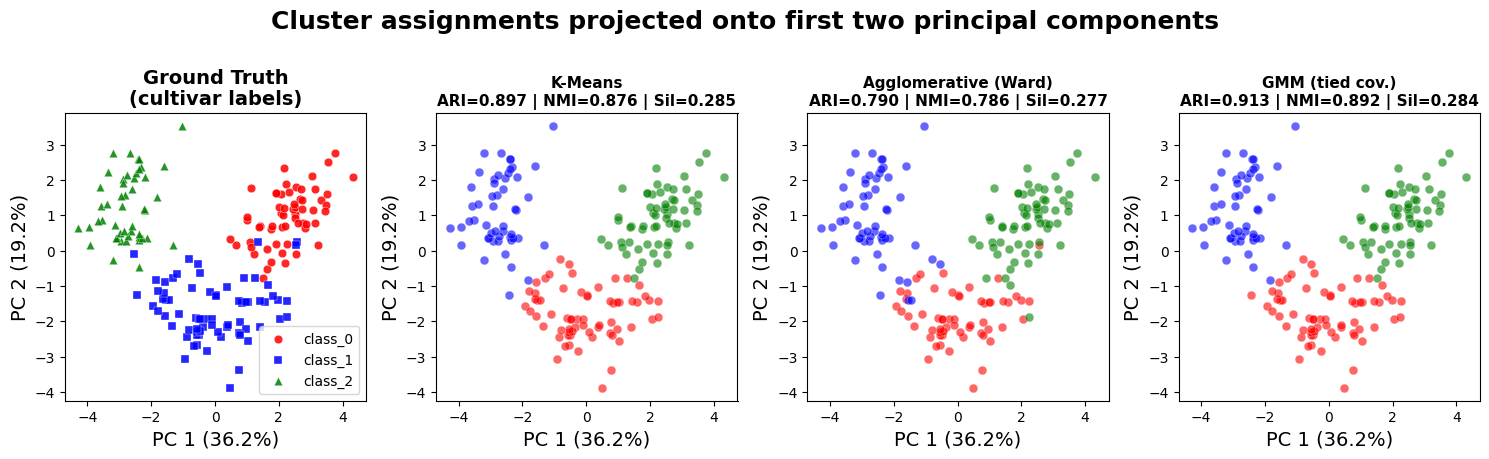

In [4]:
PALETTE = ['red', 'blue', 'green']
MARKERS = ['o', 's', '^']
methods = list(labels.keys())

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))

# Column 0: ground truth
ax = axes[0]
for k in range(3):
    mask = y_true == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=PALETTE[k], marker=MARKERS[k],
               s=38, alpha=0.85, edgecolors='white', linewidths=0.3,
               label=wine.target_names[k])
ax.set_title('Ground Truth\n(cultivar labels)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')

# Columns 1–3: clustering results
for ax, (name, label) in zip(axes[1:], labels.items()):
    ari = adjusted_rand_score(y_true, label)
    nmi = normalized_mutual_info_score(y_true, label)
    sil = silhouette_score(X, label)
    for k in range(3):
        mask = label == k
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=PALETTE[k], marker='o',
                   s=40, alpha=0.6, edgecolors='white', linewidths=0.3)
    ax.set_title(f'{name}\nARI={ari:.3f} | NMI={nmi:.3f} | Sil={sil:.3f}', fontsize=11, fontweight='bold')

for ax in axes:
    ax.set_xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=14)
    ax.set_ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=14)

fig.suptitle('Cluster assignments projected onto first two principal components',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Confusion matrices (predicted vs ground truth)

In [5]:
def align_labels(y_true, y_pred):
    """
    Permute predicted cluster labels to best match true labels,
    using greedy column assignment on the confusion matrix.
    Returns the remapped predicted labels.
    """
    cm = confusion_matrix(y_true, y_pred)   # shape (n_true_classes, n_pred_clusters)
    n = cm.shape[0]
    used_true = set()
    mapping = {}

    # Assign each predicted cluster to the true class it overlaps most,
    # without reusing a true class (greedy by descending overlap count).
    order = np.dstack(np.unravel_index(np.argsort(-cm, axis=None), cm.shape))[0]
    for true_k, pred_k in order:
        if pred_k not in mapping and true_k not in used_true:
            mapping[pred_k] = true_k
            used_true.add(true_k)
        if len(mapping) == n:
            break

    remapped = np.array([mapping[p] for p in y_pred])
    return remapped

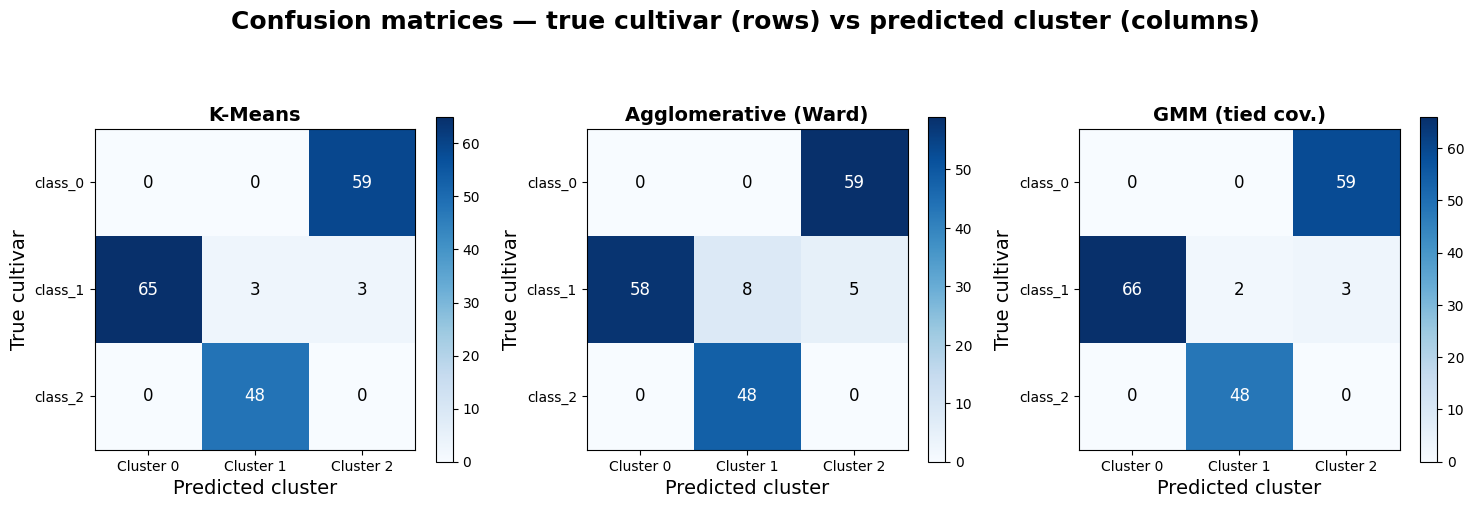

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, label) in zip(axes, labels.items()):
    cm = confusion_matrix(y_true, label)  # use unaligned labels
    # label_aligned = align_labels(y_true, label)
    # cm = confusion_matrix(y_true, label_aligned)
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max())
    
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels([f'Cluster {i}' for i in range(3)], fontsize=10)  # unaligned labels
    # ax.set_xticklabels(wine.target_names, fontsize=10)
    ax.set_yticklabels(wine.target_names, fontsize=10)
    ax.set_xlabel('Predicted cluster', fontsize=14)
    ax.set_ylabel('True cultivar', fontsize=14)
    ax.set_title(name, fontsize=14, fontweight='bold')
    
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=12,
                    color='white' if cm[i, j] > cm.max() * 0.55 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Confusion matrices — true cultivar (rows) vs predicted cluster (columns)',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Agglomerative dendrogram

A dendrogram is unique to hierarchical clustering and shows the full merge history — the height of each branch indicates the distance (Ward linkage: increase in within-cluster variance) at which two groups were joined. The three-cluster solution corresponds to cutting the tree at the level of the three tallest branches.

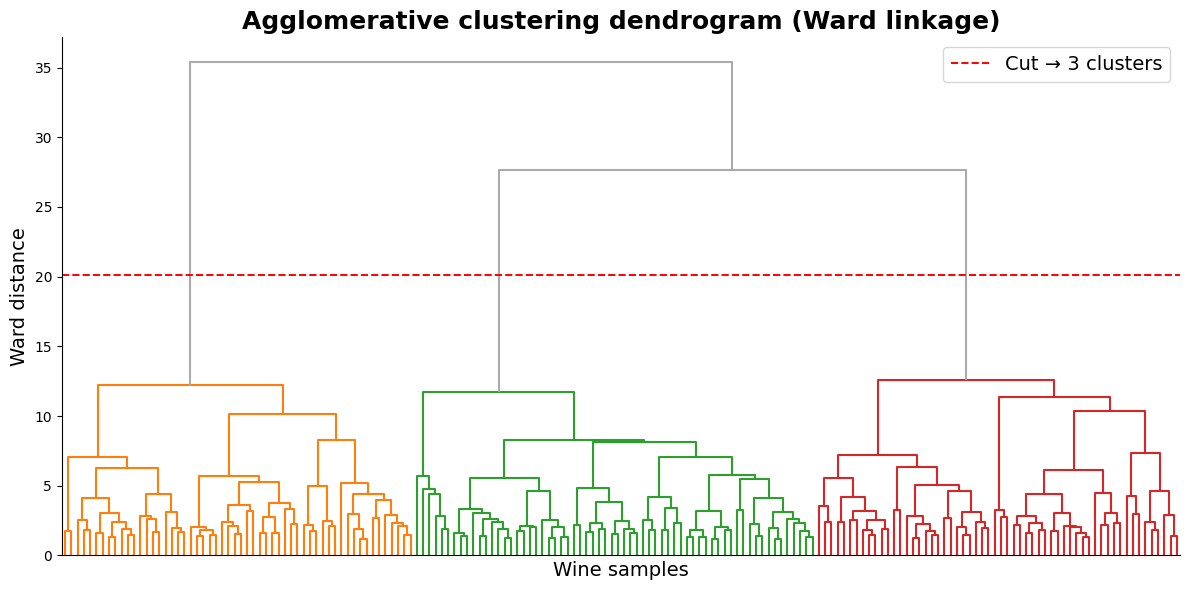

In [7]:
# Perform agglomerative clustering and return a linkage matrix Z of shape (n-1, 4)
# where each row represents one merge step in the clustering process.
# Row i: 
#   Z[i] = [c1, c2, d, n]
# Example: [2, 5, 1.3, 4]
#   - Merge cluster 2 and cluster 5 at distance 1.3
#   - Resulting cluster contains 4 original points
Z = sp_linkage(X, method='ward')

# Color threshold: height just below the 3rd-largest merge distance
merge_heights = sorted(Z[:, 2])
cut_height    = (merge_heights[-3] + merge_heights[-2]) / 2

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=cut_height,
           above_threshold_color='#AAAAAA')
ax.axhline(cut_height, color='red', linewidth=1.4,
           linestyle='--', label=f'Cut → 3 clusters')
ax.set_xlabel('Wine samples', fontsize=14)
ax.set_ylabel('Ward distance', fontsize=14)
ax.set_title('Agglomerative clustering dendrogram (Ward linkage)', fontsize=18, fontweight='bold')
ax.legend(fontsize=14)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. GMM soft membership probabilities

Unlike k-means and agglomerative clustering (which make hard assignments), GMM assigns each point a probability of belonging to each component. Points near cluster boundaries receive mixed probabilities, while confident points have one probability close to 1. Visualizing this reveals where the model is uncertain.

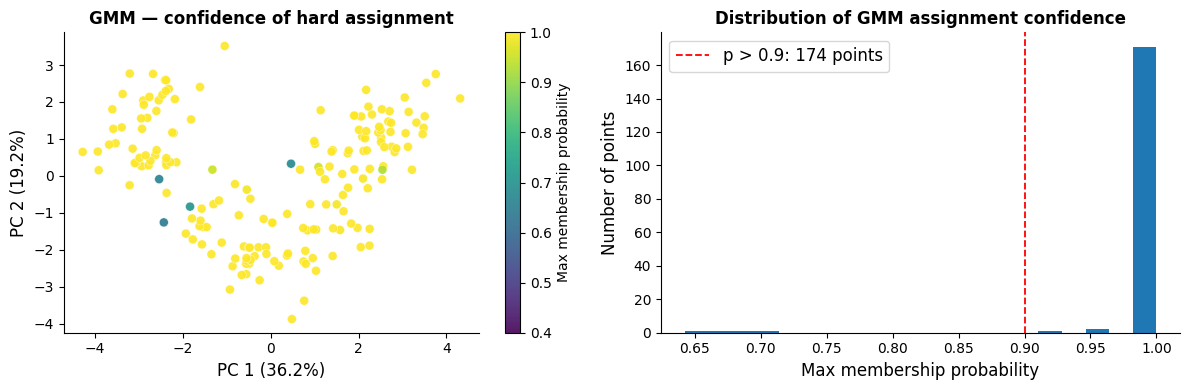

Points with max membership probability < 0.90: 4 (2.2%)
Points with max membership probability > 0.99: 171


In [8]:
proba = gmm.predict_proba(X)   # shape (178, 3)
max_proba = proba.max(axis=1)  # confidence of the winning assignment
hard_labels = gmm.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: scatter colored by max membership probability 
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=max_proba, cmap='viridis',
                     s=42, alpha=0.9, vmin=0.4, vmax=1.0,
                     edgecolors='white', linewidths=0.3)
plt.colorbar(sc, ax=axes[0], label='Max membership probability')
axes[0].set_title('GMM — confidence of hard assignment', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
axes[0].set_ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
axes[0].spines[['top', 'right']].set_visible(False)

# Right: histogram of max membership probabilities
axes[1].hist(max_proba, bins=20, linewidth=0.5)
axes[1].axvline(0.9, color='red', linestyle='--', linewidth=1.3,
                label=f'p > 0.9: {(max_proba > 0.9).sum()} points')
axes[1].set_xlabel('Max membership probability', fontsize=12)
axes[1].set_ylabel('Number of points', fontsize=12)
axes[1].set_title('Distribution of GMM assignment confidence', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

uncertain = (max_proba < 0.9).sum()
print(f"Points with max membership probability < 0.90: {uncertain} ({uncertain/len(X):.1%})")
print(f"Points with max membership probability > 0.99: {(max_proba > 0.99).sum()}")

## 7. Disagreement analysis

Where do the three methods disagree? Identifying points where algorithms produce different assignments pinpoints the most ambiguous samples in the dataset.

Pairwise ARI between methods
  K-Means vs Agglomerative : ARI = 0.8530
  K-Means vs GMM           : ARI = 0.9836
  Agglomerative vs GMM     : ARI = 0.8381

Pairwise disagreement
  K-Means vs Agglomerative : 9 points assigned differently (5.1%)
  K-Means vs GMM           : 1 points assigned differently (0.6%)
  Agglomerative vs GMM     : 10 points assigned differently (5.6%)



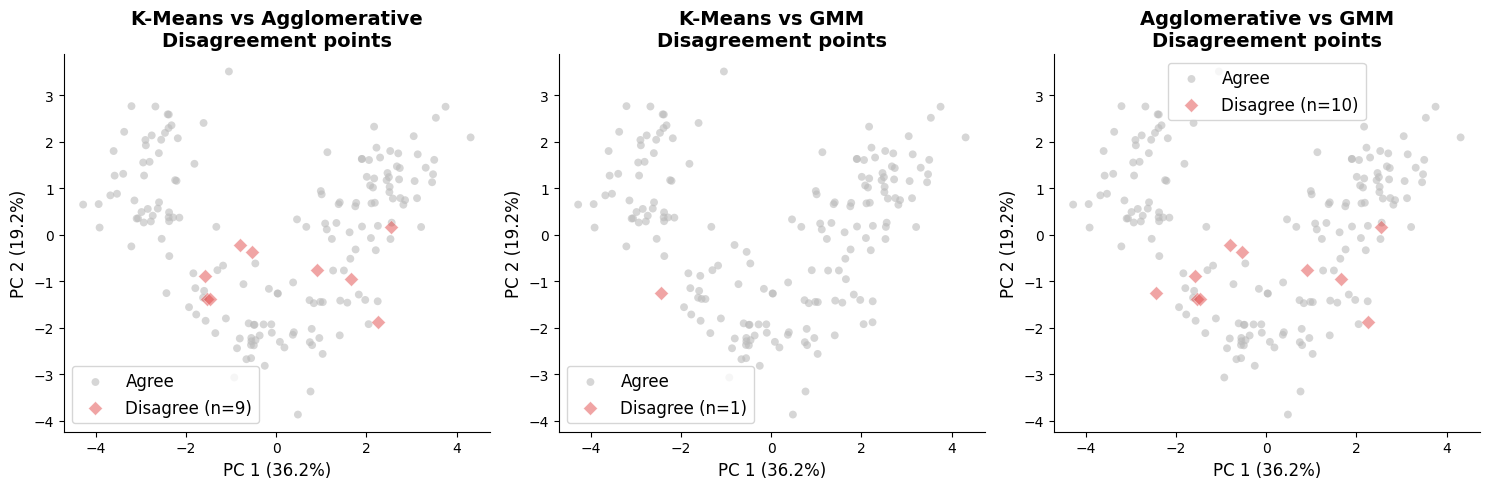

In [9]:
label_km  = labels['K-Means']
label_agg = labels['Agglomerative (Ward)']
label_gmm = labels['GMM (tied cov.)']

# Pairwise agreement between methods using ARI (permutation-invariant)
pairs = [
    ('K-Means vs Agglomerative', label_km,  label_agg),
    ('K-Means vs GMM',           label_km,  label_gmm),
    ('Agglomerative vs GMM',     label_agg, label_gmm),
]
print('Pairwise ARI between methods')
for name, a, b in pairs:
    print(f'  {name:<25}: ARI = {adjusted_rand_score(a, b):.4f}')

# Map each predicted cluster to its dominant true cultivar via majority vote,
# using sklearn's confusion_matrix — no external alignment needed.
def map_to_truth(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)   # rows = true, cols = predicted
    mapping = cm.argmax(axis=0)             # dominant true label per cluster
    return mapping[y_pred]

km_mapped  = map_to_truth(y_true, label_km)
agg_mapped = map_to_truth(y_true, label_agg)
gmm_mapped = map_to_truth(y_true, label_gmm)

disagree = np.zeros((X.shape[0], 3), dtype=bool)
disagree[:, 0] = km_mapped != agg_mapped
disagree[:, 1] = km_mapped != gmm_mapped
disagree[:, 2] = agg_mapped != gmm_mapped

print('\nPairwise disagreement')
for i, name in enumerate(pairs):
    print(f'  {name[0]:<25}: {disagree[:,i].sum()} points assigned differently ({disagree[:,i].mean():.1%})')
print()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, name in enumerate(pairs):
    ax[i].scatter(X_pca[~disagree[:,i], 0], X_pca[~disagree[:,i], 1],
                  c='#BBBBBB', s=32, alpha=0.6, label='Agree', edgecolors='none')
    ax[i].scatter(X_pca[disagree[:,i], 0],  X_pca[disagree[:,i], 1],
                  c='#E24B4A', s=50, alpha=0.5, marker='D',
                  label=f'Disagree (n={disagree[:,i].sum()})', edgecolors='white', linewidths=0.4)
    ax[i].set_xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
    ax[i].set_ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
    ax[i].legend(fontsize=12)
    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].set_title(f'{name[0]}\nDisagreement points', fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.show()

---
## 8. Dimensionality reduction for visualization: PCA, t-SNE, and UMAP

PCA is a *linear* projection — it finds the directions of maximum variance but cannot capture curved or non-linear structure. **t-SNE** and **UMAP** are non-linear methods that can reveal cluster topology that PCA compresses away.

| Method | Preserves | Notes |
|:---|:---|:---|
| **PCA** | Global variance / covariance | Linear; fast; axes are interpretable |
| **t-SNE** | Local neighborhood structure | Non-linear; distances between clusters are not meaningful; perplexity controls neighborhood size |
| **UMAP** | Both local and some global structure | Non-linear; faster than t-SNE; `n_neighbors` and `min_dist` control layout |

Each plot shows the same cluster labels (from K-Means, Agglomerative, and GMM) projected through a different embedding, alongside the ground truth.

In [10]:
try:
    import umap
except ModuleNotFoundError:
    !pip install umap-learn

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 9.1 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ----- ---------------------------------- 5.0/38.1 MB 23.7 MB/s eta 0:00:02
   ---------- ----------------------------- 10.0/38.1 MB 24.0 MB/s eta 0:00:02
   ----------- ---------------------------- 11.3/38.1 MB 24.2 MB/s eta 0:00:02
   ------------ --------------------------- 11.5/38.1 MB 16.4 MB/s eta 0:00:02
   ------------ --------------------------- 12.1/38.1 MB 12.8 MB/s eta 0:00:03
   ------------- -------------------------- 13.1/38.1 MB 10.5 MB/s eta 0:00:03
   -------------- ------------------------- 14.2/38.1 MB 9.5 MB/s eta 0:00:03
   --------------- ------------------------ 14.9/38.1 MB 9.1 MB/s eta 0:00:03
   ---------------- ----------------------- 16.0/38.1 MB 8.5 MB/s eta 0:00:03
   --


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


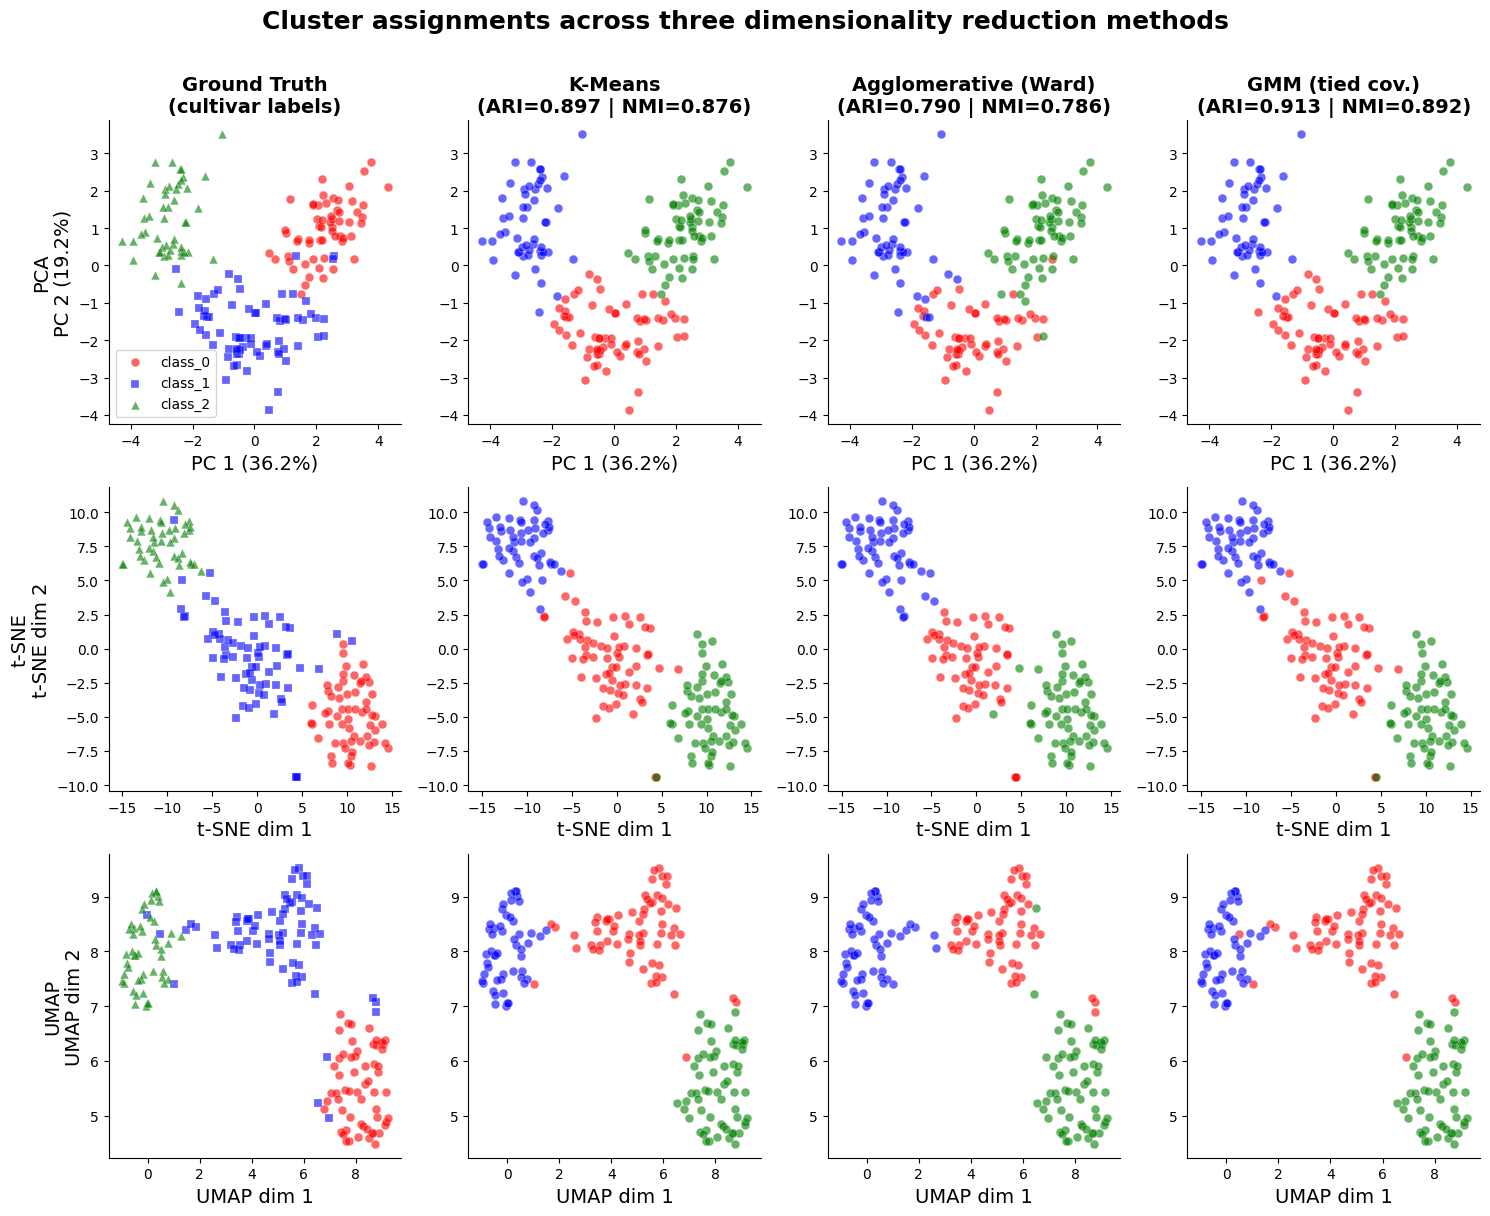

In [11]:
from sklearn.manifold import TSNE
import umap
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# Compute embeddings (fit on scaled data, same X used for clustering)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X)

# Plot: 3 embeddings × 4 columns (ground truth + 3 clustering methods)
embeddings = [
    ('PCA', X_pca, f'PC 1 ({pca.explained_variance_ratio_[0]:.1%})', 
     f'PC 2 ({pca.explained_variance_ratio_[1]:.1%})'),
    ('t-SNE', X_tsne, 't-SNE dim 1', 't-SNE dim 2'),
    ('UMAP',X_umap, 'UMAP dim 1', 'UMAP dim 2'),
]

fig, axes = plt.subplots(3, 4, figsize=(15, 12))

for row, (emb_name, X_emb, xlabel, ylabel) in enumerate(embeddings):
    # Column 0: ground truth
    ax = axes[row, 0]
    for k in range(3):
        mask = y_true == k
        ax.scatter(X_emb[mask, 0], X_emb[mask, 1], c=PALETTE[k], marker=MARKERS[k],
                   s=40, alpha=0.6, edgecolors='white', linewidths=0.3,
                   label=wine.target_names[k])
    if row == 0:
        ax.set_title('Ground Truth\n(cultivar labels)', fontsize=14, fontweight='bold')
        ax.legend(fontsize=10, loc='best')
    ax.set_ylabel(f'{emb_name}\n{ylabel}', fontsize=14)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.spines[['top', 'right']].set_visible(False)

    # Columns 1–3: clustering results
    for col, (name, label) in enumerate(labels.items(), start=1):
        ax = axes[row, col]
        for k in range(3):
            mask = label == k
            ax.scatter(X_emb[mask, 0], X_emb[mask, 1], c=PALETTE[k], 
                       s=40, alpha=0.6, edgecolors='white', linewidths=0.3)
        if row == 0:
            ari = adjusted_rand_score(y_true, label)
            nmi = normalized_mutual_info_score(y_true, label)
            ax.set_title(f'{name}\n(ARI={ari:.3f} | NMI={nmi:.3f})', fontsize=14, fontweight='bold')
        ax.set_xlabel(xlabel, fontsize=14)
        ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Cluster assignments across three dimensionality reduction methods',
    fontsize=18, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

### Interpreting the PCA, t-SNE, and UMAP plots

#### PCA (row 1)
PCA finds the two linear directions of maximum variance in the 13-dimensional feature space. The three cultivar groups are **visibly separated** but with some overlap. This tells us the clusters are genuinely distinct in the original space — a linear projection is already enough to see most of the separation — but that the boundaries are not perfectly clean in two dimensions. The 55% explained variance figure confirms that nearly half the information is lost in this projection, which accounts for the residual overlap.

Because PCA is linear, it preserves **global structure**: relative distances and orientations between clusters roughly reflect their true distances in the full feature space. This makes it the most honest summary projection, but it can miss non-linear arrangements.

#### t-SNE (row 2)
t-SNE optimises a 2-D layout so that points which are **close neighbors in the original high-dimensional space** also end up close in the plot. It does this by converting distances into probabilities and minimising the divergence between the high-dimensional and low-dimensional probability distributions (using a Student-t distribution in 2-D, which gives it the "t" in its name).

The result on the Wine data shows **three well-separated, compact islands** with very little overlap — cleaner than PCA. This is typical of t-SNE: it aggressively pulls tight local groups together and pushes different groups apart, making cluster structure pop visually. However, two important caveats apply:

- **Distances between clusters are not meaningful.** The gaps between the three islands in the t-SNE plot say nothing about how far apart the cultivars are in the original 13-dimensional space. t-SNE sacrifices global distances to preserve local topology.
- **Cluster sizes and shapes are distorted.** A large island does not necessarily mean a large or spread-out cluster in the original space.
- **The result depends on hyperparameters.** The `perplexity` parameter (set to 30 here) controls the effective neighborhood size. Different values can produce quite different layouts, so t-SNE plots should always be interpreted with the hyperparameter settings in mind.

#### UMAP (row 3)
UMAP is based on manifold learning and topological data analysis. Like t-SNE it preserves local neighborhood structure, but it also makes a stronger effort to preserve **global structure** — the relative positions of clusters in the UMAP plot are more representative of their true relationships in the original space than in t-SNE.

On the Wine data, UMAP produces the **clearest visual separation** of the three: compact and well-spaced groups. There are two reasons for this:

1. **The Wine clusters have a genuine manifold structure.** Each cultivar occupies a relatively tight, low-dimensional region of the 13-dimensional feature space. UMAP is particularly good at finding and unfolding such manifolds, whereas PCA (being linear) cannot bend around non-linear arrangements, and t-SNE can over-compress or distort them.
2. **UMAP's `min_dist` parameter** (set to 0.1 here) controls how tightly points are packed within a cluster in the embedding. Small values allow dense, compact islands that look well-separated even if the underlying clusters are only moderately distinct.

**Notes:** PCA is the most transparent projection (interpretable axes, preserves global distances) but misses non-linear structure. t-SNE excels at revealing local cluster topology but distorts global distances. UMAP offers a balance — it tends to produce the cleanest visual separation while preserving more global structure than t-SNE. None of them should be used *for* clustering; they are tools for *visualizing* the clusters that algorithms found in the full-dimensional space.

---
## Summary: Metric comparison

In [12]:
display(metrics_df)

,ARI,NMI,Silhouette,Cluster sizes
Method,,,,
K-Means,0.8975,0.8759,0.2849,[65 51 62]
Agglomerative (Ward),0.7899,0.7865,0.2774,[58 56 64]
GMM (tied cov.),0.9134,0.8920,0.2843,[66 50 62]


### Key observations:

- K-Means and GMM achieve higher ARI than Agglomerative on this dataset. The three cultivar groups have relatively compact, roughly Gaussian structure in the scaled feature space — well suited to both algorithms.

- GMM (tied covariance) matches or slightly exceeds K-Means in ARI. The shared covariance matrix allows components to be elliptical rather than spherical, capturing the natural elongation of the wine clusters.

- Agglomerative (Ward) achieves lower ARI. Ward linkage also minimizes within-cluster variance, but the greedy merge order can produce sub-optimal partitions compared to the global optimization of K-Means. Its key advantage is the dendrogram: it does not require k in advance and exposes the full merge hierarchy.

- GMM provides soft membership probabilities — unique among the three. Points near cluster boundaries receive mixed probabilities, quantifying assignment uncertainty rather than forcing a hard decision.

#### Note: 
If you would like to learn more about UMAP, [this webpage](https://pair-code.github.io/understanding-umap/) is a great resource with a comparison of t-SNE and UMAP. You can also play around with the hyperparameters to see how they affect the 2D UMAP embedding.